### System Setup and Initialization

In [2]:
# !pip install numpy matplotlib tqdm heapq

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import heapq
from tqdm import tqdm

# Global plot configurations
plt.rcParams.update({
    'font.size': 10, 
    'figure.figsize': (12, 6), 
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--'
})

# Simulation constants based on the reference paper
NUM_TRIPS = 1200      # Total iterations per simulation
DISCARD_TRIPS = 1000  # Number of initial trips to ignore (transient state)

### Core Simulation Engine (Nonlinear Map Model)

In [4]:
def simulate_all_metrics(gamma, S_params, num_trips=NUM_TRIPS, discard=DISCARD_TRIPS):
    """
    Simulates shuttle buses using a Priority Queue to strictly enforce chronological order.
    Returns headway and tour time histories for both buses.
    """
    # Priority queue stores tuples of: (arrival_time, bus_id, trip_id)
    future_arrivals = []
    
    # Initial conditions to match dimensionless parameters
    # Bus 0 arrives at t=0.0, Bus 1 arrives at t=0.5
    heapq.heappush(future_arrivals, (0.0, 0, 0))
    heapq.heappush(future_arrivals, (0.5, 1, 0))
    
    # State tracking
    last_arrival_time = -0.5  # Assumed previous arrival to give initial headway
    
    history = {'h0': [], 'h1': [], 'tour0': [], 'tour1': []}
    
    while future_arrivals:
        current_time, bus_id, trip_id = heapq.heappop(future_arrivals)
        
        if trip_id >= num_trips:
            break
            
        # Calculate Headway: time since the VERY LAST bus arrived at the origin
        headway = current_time - last_arrival_time
        
        # Update global state
        last_arrival_time = current_time
        
        # Calculate Tour Time for the current bus (Equation 5)
        S_i = S_params[bus_id]
        tour_time = gamma * headway + 1.0 / (1.0 + S_i * headway)
        
        # Schedule next arrival
        next_time = current_time + tour_time
        
        # Record data after transient state
        if trip_id >= discard:
            if bus_id == 0:
                history['h0'].append(headway)
                history['tour0'].append(tour_time)
            elif bus_id == 1:
                history['h1'].append(headway)
                history['tour1'].append(tour_time)
                
        # Push next trip to the queue
        heapq.heappush(future_arrivals, (next_time, bus_id, trip_id + 1))
        
    return history

### Bifurcation Diagram (Recreating Figures 2)

(d) S1=0.5, S2=0.2: 100%|██████████| 300/300 [00:00<00:00, 983.61it/s]


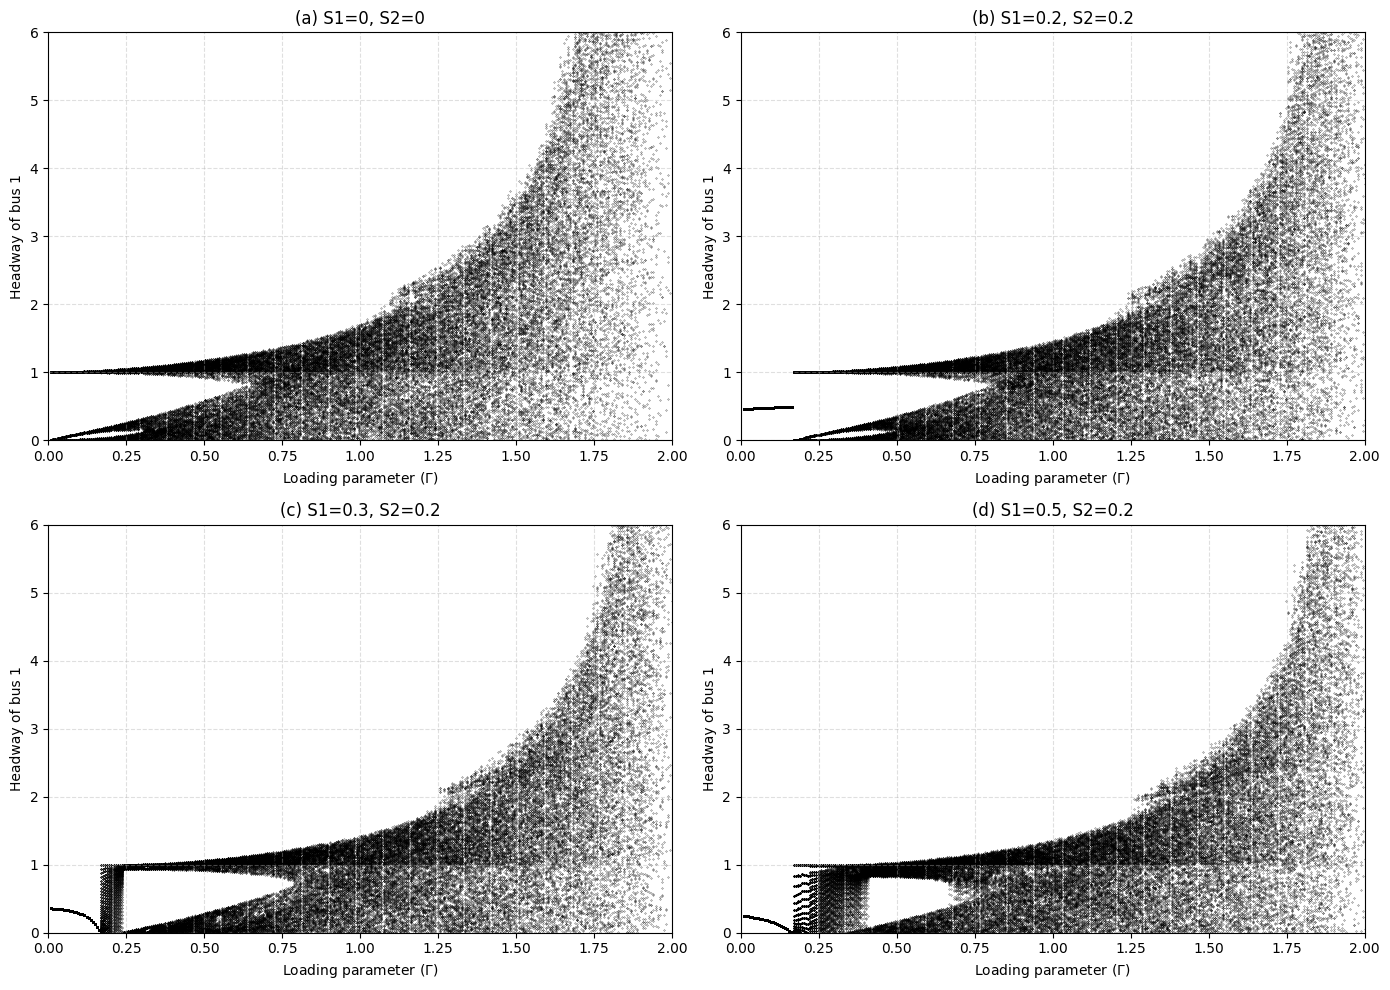

In [5]:
gamma_axis = np.linspace(0.01, 2.0, 300)
cases = [
    (0.0, 0.0, "(a) S1=0, S2=0"),
    (0.2, 0.2, "(b) S1=0.2, S2=0.2"),
    (0.3, 0.2, "(c) S1=0.3, S2=0.2"),
    (0.5, 0.2, "(d) S1=0.5, S2=0.2")
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (S1, S2, title) in enumerate(cases):
    g_plot, h_plot = [], []
    for g in tqdm(gamma_axis, desc=title):
        res = simulate_all_metrics(g, [S1, S2])
        g_plot.extend([g] * len(res['h0'])) 
        h_plot.extend(res['h0'])
        
    axes[i].scatter(g_plot, h_plot, s=0.05, color='black')
    axes[i].set_title(title)
    axes[i].set_xlabel(r"Loading parameter ($\Gamma$)")
    axes[i].set_ylabel("Headway of bus 1")
    axes[i].set_xlim(0, 2)
    axes[i].set_ylim(0, 6)

plt.tight_layout()
plt.savefig('fig2.png')
plt.show()

### Enlargements of Bifurcation Diagrams (Recreating Figure 3)

(d) S1=0.5, S2=0.2: 100%|██████████| 300/300 [00:00<00:00, 1098.73it/s]


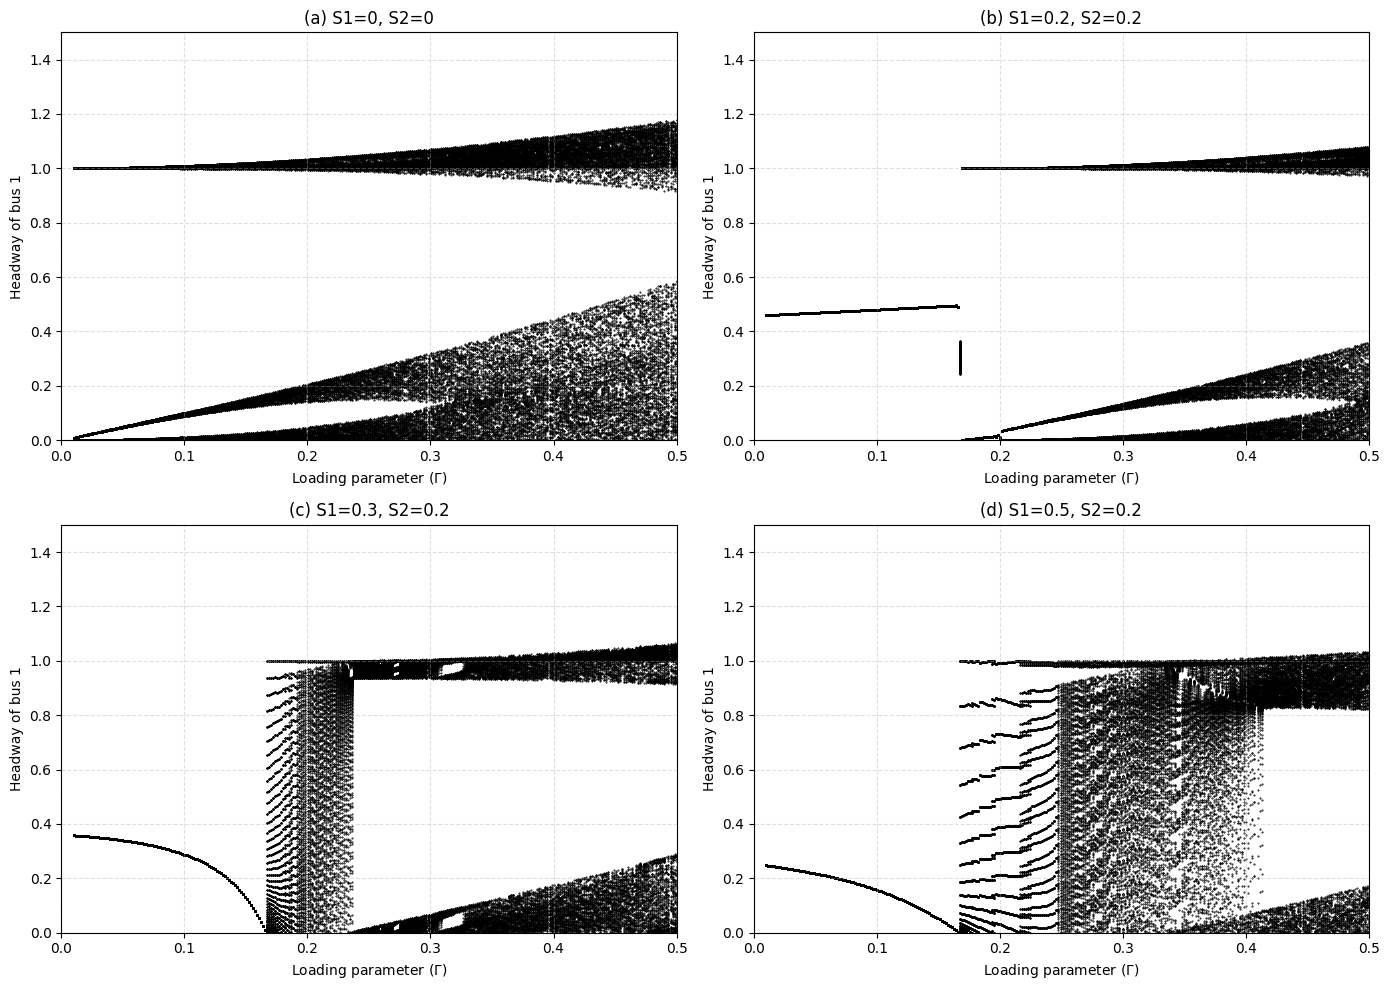

In [6]:
gamma_axis_zoom = np.linspace(0.01, 0.5, 300)
cases = [
    (0.0, 0.0, "(a) S1=0, S2=0"),
    (0.2, 0.2, "(b) S1=0.2, S2=0.2"),
    (0.3, 0.2, "(c) S1=0.3, S2=0.2"),
    (0.5, 0.2, "(d) S1=0.5, S2=0.2")
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (S1, S2, title) in enumerate(cases):
    g_plot, h_plot = [], []
    for g in tqdm(gamma_axis_zoom, desc=title):
        res = simulate_all_metrics(g, [S1, S2], num_trips=1200, discard=1000)
        g_plot.extend([g] * len(res['h0'])) 
        h_plot.extend(res['h0'])
        
    axes[i].scatter(g_plot, h_plot, s=0.2, color='black')
    axes[i].set_title(title)
    axes[i].set_xlabel(r"Loading parameter ($\Gamma$)")
    axes[i].set_ylabel("Headway of bus 1")
    axes[i].set_xlim(0, 0.5)
    axes[i].set_ylim(0, 1.5)

plt.tight_layout()
plt.savefig('fig3.png')
plt.show()

### Tour Time Analysis (Recreating Figure 4)

100%|██████████| 300/300 [00:00<00:00, 939.01it/s]


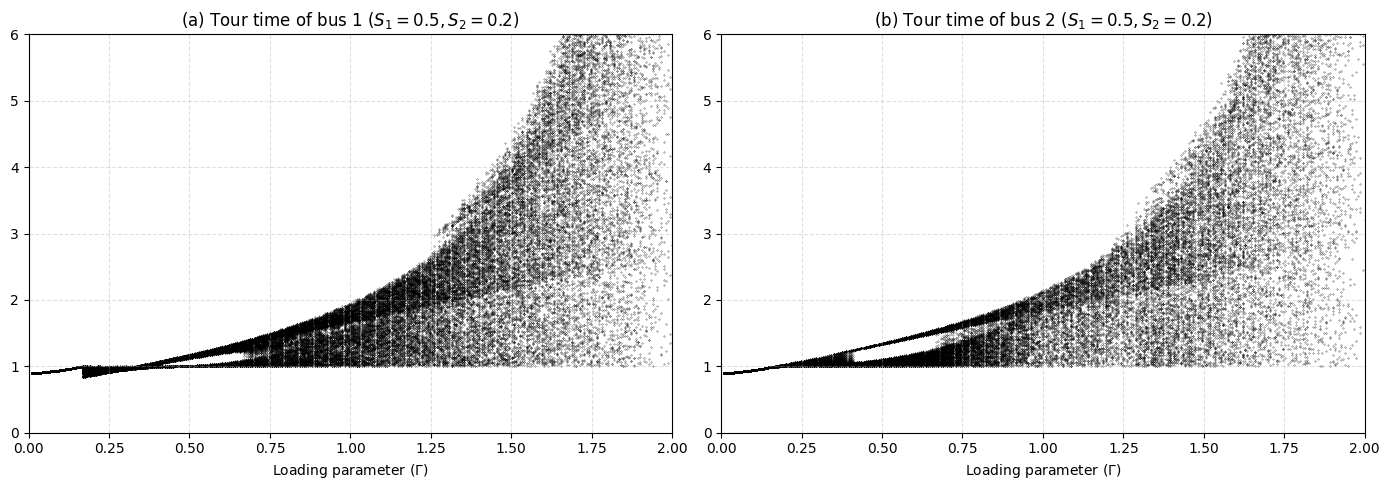

In [7]:
S1, S2 = 0.5, 0.2

g_plot_tour1, tour1_plot = [], []
g_plot_tour2, tour2_plot = [], []

for g in tqdm(gamma_axis):
    res = simulate_all_metrics(g, [S1, S2])

    g_plot_tour1.extend([g] * len(res['tour0']))
    tour1_plot.extend(res['tour0'])
    
    g_plot_tour2.extend([g] * len(res['tour1']))
    tour2_plot.extend(res['tour1']) 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(g_plot_tour1, tour1_plot, s=0.05, color='black')
ax1.set_title(f"(a) Tour time of bus 1 ($S_1={S1}, S_2={S2}$)")
ax1.set_xlabel(r"Loading parameter ($\Gamma$)")
ax1.set_xlim(0, 2)
ax1.set_ylim(0, 6)

ax2.scatter(g_plot_tour2, tour2_plot, s=0.05, color='black')
ax2.set_title(f"(b) Tour time of bus 2 ($S_1={S1}, S_2={S2}$)")
ax2.set_xlabel(r"Loading parameter ($\Gamma$)")
ax2.set_xlim(0, 2)
ax2.set_ylim(0, 6)

plt.tight_layout()
plt.savefig('fig4.png')
plt.show()

### Enlargements of Tour Times (Recreating Figure 5)

100%|██████████| 300/300 [00:00<00:00, 1037.76it/s]


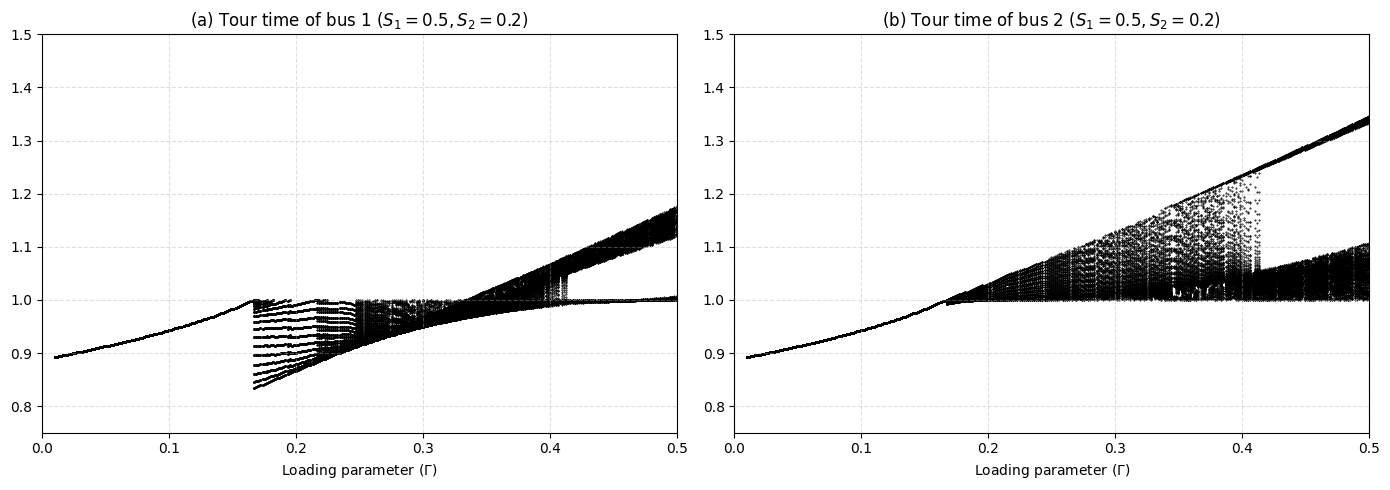

In [8]:
S1, S2 = 0.5, 0.2

g_plot_zoom1, tour1_plot_zoom = [], []
g_plot_zoom2, tour2_plot_zoom = [], []

for g in tqdm(gamma_axis_zoom):
    res = simulate_all_metrics(g, [S1, S2], num_trips=1200, discard=1000)

    g_plot_zoom1.extend([g] * len(res['tour0']))
    tour1_plot_zoom.extend(res['tour0'])

    g_plot_zoom2.extend([g] * len(res['tour1']))
    tour2_plot_zoom.extend(res['tour1']) 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(g_plot_zoom1, tour1_plot_zoom, s=0.2, color='black')
ax1.set_title(f"(a) Tour time of bus 1 ($S_1={S1}, S_2={S2}$)")
ax1.set_xlabel(r"Loading parameter ($\Gamma$)")
ax1.set_xlim(0, 0.5)
ax1.set_ylim(0.75, 1.5)

ax2.scatter(g_plot_zoom2, tour2_plot_zoom, s=0.2, color='black')
ax2.set_title(f"(b) Tour time of bus 2 ($S_1={S1}, S_2={S2}$)")
ax2.set_xlabel(r"Loading parameter ($\Gamma$)")
ax2.set_xlim(0, 0.5)
ax2.set_ylim(0.75, 1.5)

plt.tight_layout()
plt.savefig('fig5.png')
plt.show()

### Return Map (Recreating Figure 6)

<>:14: SyntaxWarning: invalid escape sequence '\G'
<>:14: SyntaxWarning: invalid escape sequence '\G'
/tmp/ipykernel_1735110/3967726688.py:14: SyntaxWarning: invalid escape sequence '\G'
  axes[i].set_title(f"$\Gamma = {g}$")


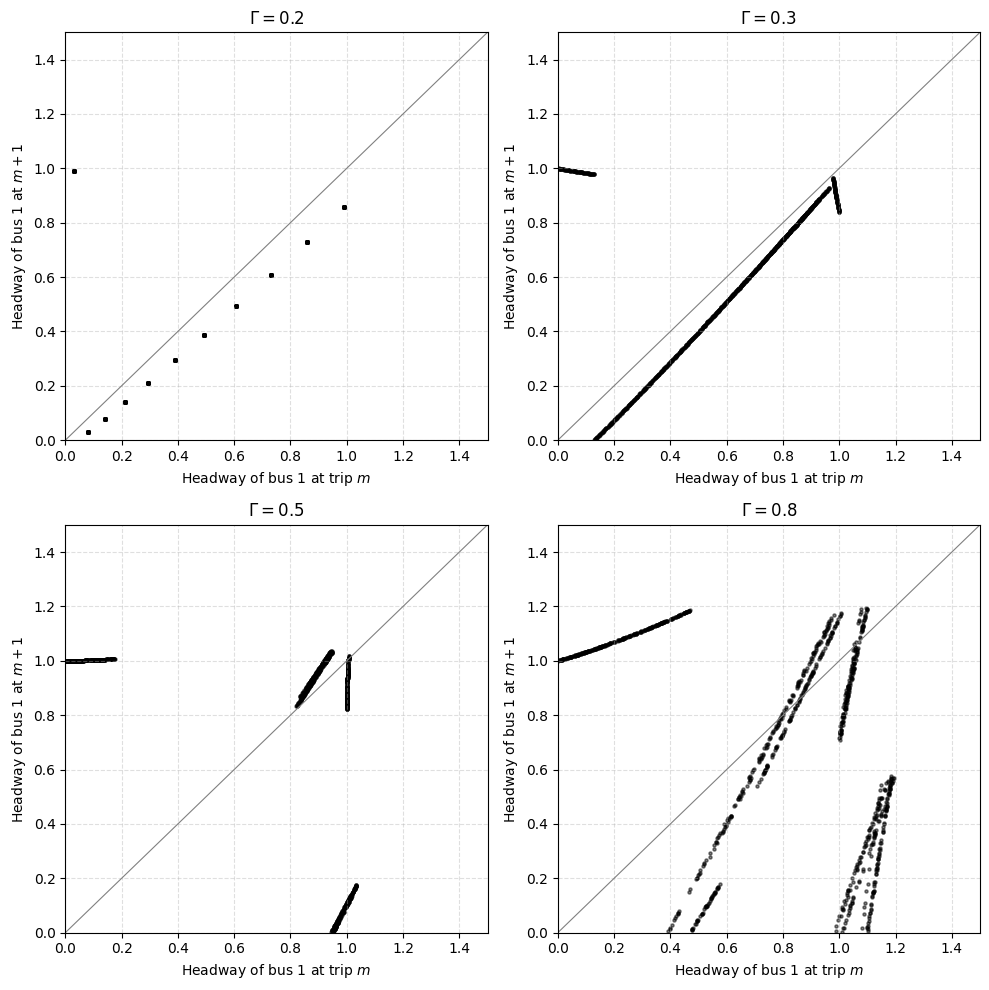

In [9]:
gamma_values = [0.2, 0.3, 0.5, 0.8]
S1, S2 = 0.5, 0.2

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for i, g in enumerate(gamma_values):
    res = simulate_all_metrics(g, [S1, S2], num_trips=2000, discard=1000)
    h_seq = res['h0']
    axes[i].scatter(h_seq[:-1], h_seq[1:], s=5, color='black', alpha=0.5)
    
    axes[i].plot([0, 1.5], [0, 1.5], color='gray', linestyle='-', linewidth=0.8)
    
    axes[i].set_title(f"$\Gamma = {g}$")
    axes[i].set_xlabel("Headway of bus 1 at trip $m$")
    axes[i].set_ylabel("Headway of bus 1 at $m+1$")
    axes[i].set_xlim(0, 1.5)
    axes[i].set_ylim(0, 1.5)

plt.tight_layout()
plt.savefig('fig6.png')
plt.show()

### Statistical Measures: Mean & RMS (Recreating Figure 7)

<>:25: SyntaxWarning: invalid escape sequence '\D'
<>:26: SyntaxWarning: invalid escape sequence '\D'
<>:36: SyntaxWarning: invalid escape sequence '\D'
<>:37: SyntaxWarning: invalid escape sequence '\D'
<>:47: SyntaxWarning: invalid escape sequence '\D'
<>:48: SyntaxWarning: invalid escape sequence '\D'
<>:58: SyntaxWarning: invalid escape sequence '\D'
<>:59: SyntaxWarning: invalid escape sequence '\D'
<>:25: SyntaxWarning: invalid escape sequence '\D'
<>:26: SyntaxWarning: invalid escape sequence '\D'
<>:36: SyntaxWarning: invalid escape sequence '\D'
<>:37: SyntaxWarning: invalid escape sequence '\D'
<>:47: SyntaxWarning: invalid escape sequence '\D'
<>:48: SyntaxWarning: invalid escape sequence '\D'
<>:58: SyntaxWarning: invalid escape sequence '\D'
<>:59: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1735110/637919428.py:25: SyntaxWarning: invalid escape sequence '\D'
  axes[0, 0].plot(gamma_axis_stats, mean_t1, label="$\Delta T_{1,a}$", color='black', linestyle='--'

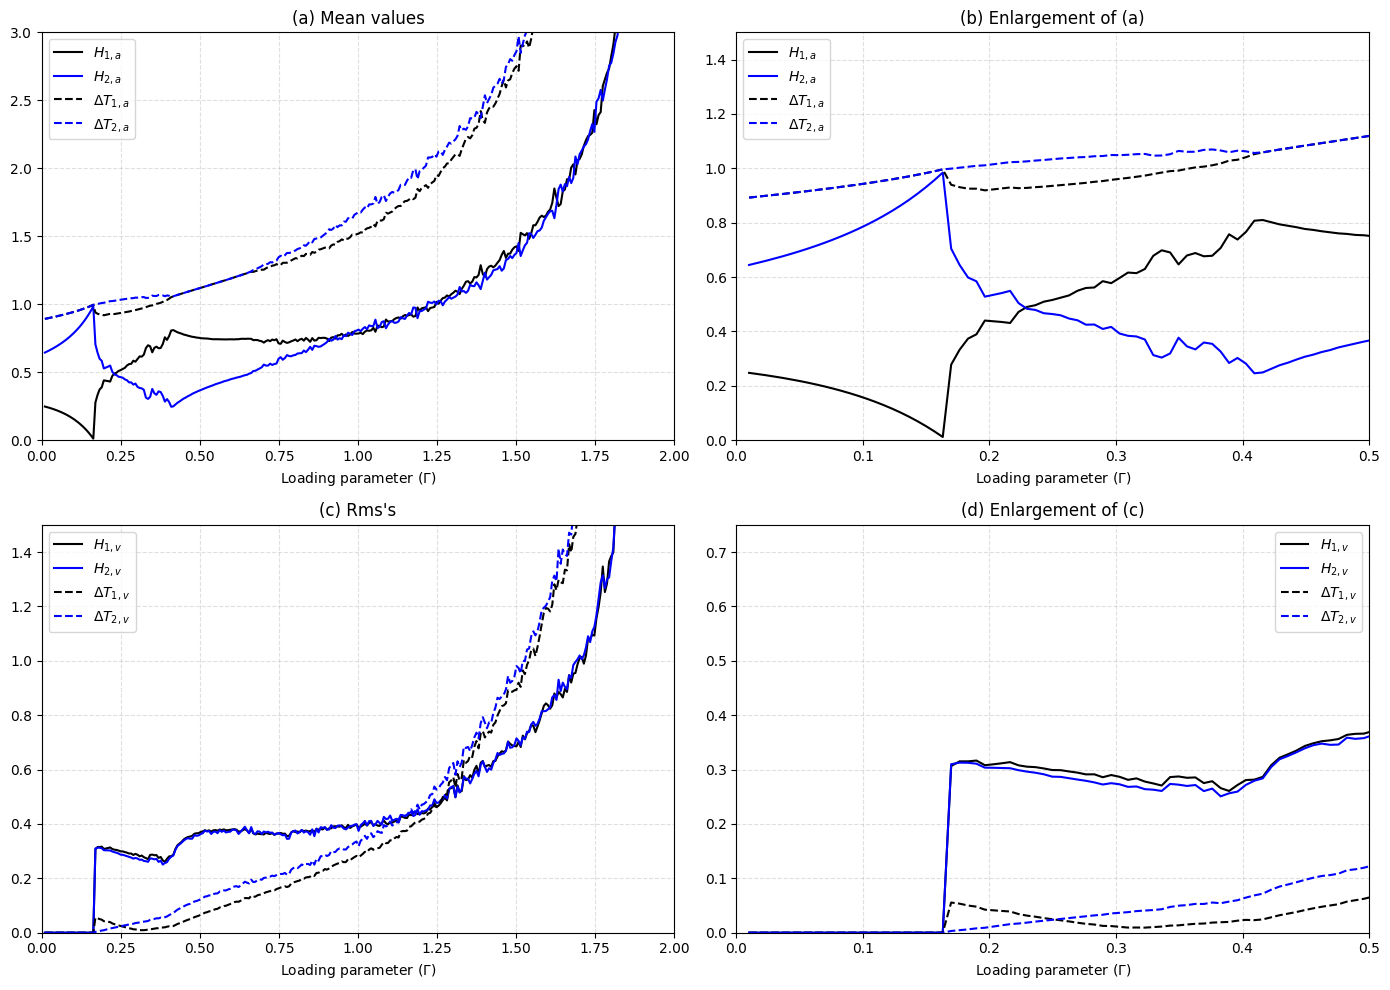

In [10]:
gamma_axis_stats = np.linspace(0.01, 2.0, 300)
S1, S2 = 0.5, 0.2

mean_h1, mean_h2, mean_t1, mean_t2 = [], [], [], []
rms_h1, rms_h2, rms_t1, rms_t2 = [], [], [], []

for g in tqdm(gamma_axis_stats):
    res = simulate_all_metrics(g, [S1, S2], num_trips=1500, discard=1000)
    
    mean_h1.append(np.mean(res['h0']))
    mean_h2.append(np.mean(res['h1']))
    mean_t1.append(np.mean(res['tour0']))
    mean_t2.append(np.mean(res['tour1']))

    rms_h1.append(np.std(res['h0']))
    rms_h2.append(np.std(res['h1']))
    rms_t1.append(np.std(res['tour0']))
    rms_t2.append(np.std(res['tour1']))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Mean values (Full range)
axes[0, 0].plot(gamma_axis_stats, mean_h1, label="$H_{1,a}$", color='black')
axes[0, 0].plot(gamma_axis_stats, mean_h2, label="$H_{2,a}$", color='blue')
axes[0, 0].plot(gamma_axis_stats, mean_t1, label="$\Delta T_{1,a}$", color='black', linestyle='--')
axes[0, 0].plot(gamma_axis_stats, mean_t2, label="$\Delta T_{2,a}$", color='blue', linestyle='--')
axes[0, 0].set_title("(a) Mean values")
axes[0, 0].set_xlabel(r"Loading parameter ($\Gamma$)")
axes[0, 0].set_xlim(0, 2)
axes[0, 0].set_ylim(0, 3)
axes[0, 0].legend()

# (b) Mean values (Zoom-in 0 -> 0.5)
axes[0, 1].plot(gamma_axis_stats, mean_h1, label="$H_{1,a}$", color='black')
axes[0, 1].plot(gamma_axis_stats, mean_h2, label="$H_{2,a}$", color='blue')
axes[0, 1].plot(gamma_axis_stats, mean_t1, label="$\Delta T_{1,a}$", color='black', linestyle='--')
axes[0, 1].plot(gamma_axis_stats, mean_t2, label="$\Delta T_{2,a}$", color='blue', linestyle='--')
axes[0, 1].set_title("(b) Enlargement of (a)")
axes[0, 1].set_xlabel(r"Loading parameter ($\Gamma$)")
axes[0, 1].set_xlim(0, 0.5)
axes[0, 1].set_ylim(0, 1.5) 
axes[0, 1].legend()

# (c) RMS values (Full range)
axes[1, 0].plot(gamma_axis_stats, rms_h1, label="$H_{1,v}$", color='black')
axes[1, 0].plot(gamma_axis_stats, rms_h2, label="$H_{2,v}$", color='blue')
axes[1, 0].plot(gamma_axis_stats, rms_t1, label="$\Delta T_{1,v}$", color='black', linestyle='--')
axes[1, 0].plot(gamma_axis_stats, rms_t2, label="$\Delta T_{2,v}$", color='blue', linestyle='--')
axes[1, 0].set_title("(c) Rms's")
axes[1, 0].set_xlabel(r"Loading parameter ($\Gamma$)")
axes[1, 0].set_xlim(0, 2)
axes[1, 0].set_ylim(0, 1.5)
axes[1, 0].legend()

# (d) RMS values (Zoom-in 0 -> 0.5)
axes[1, 1].plot(gamma_axis_stats, rms_h1, label="$H_{1,v}$", color='black')
axes[1, 1].plot(gamma_axis_stats, rms_h2, label="$H_{2,v}$", color='blue')
axes[1, 1].plot(gamma_axis_stats, rms_t1, label="$\Delta T_{1,v}$", color='black', linestyle='--')
axes[1, 1].plot(gamma_axis_stats, rms_t2, label="$\Delta T_{2,v}$", color='blue', linestyle='--')
axes[1, 1].set_title("(d) Enlargement of (c)")
axes[1, 1].set_xlabel(r"Loading parameter ($\Gamma$)")
axes[1, 1].set_xlim(0, 0.5)
axes[1, 1].set_ylim(0, 0.75) 
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('fig7.png')
plt.show()

### Phase Diagram / Region Map (Recreating Figure 8)

100%|██████████| 60/60 [00:00<00:00, 84.39it/s]


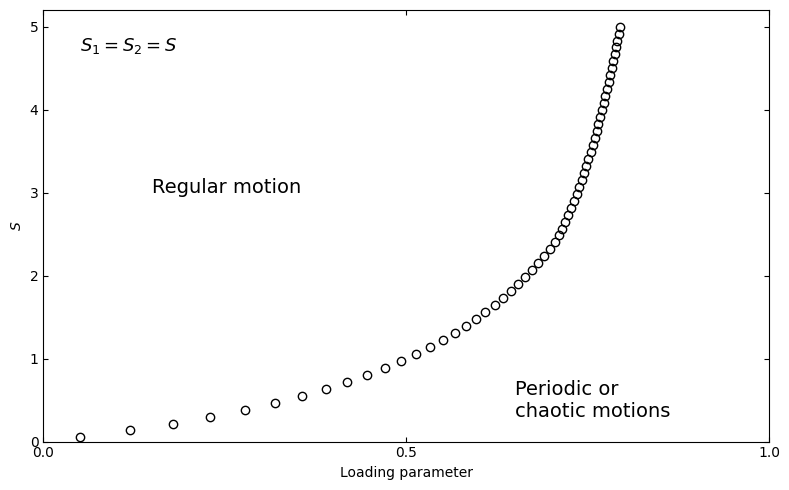

In [11]:
valid_s = np.linspace(0.05, 5.0, 60)
transition_gammas = []

for s in tqdm(valid_s):
    low = 0.01
    high = 1.0

    for _ in range(12):
        mid = (low + high) / 2
        # Goi ham mo phong tu Cell 2
        res = simulate_all_metrics(mid, [s, s], num_trips=1200, discard=1000)
        rms = np.std(res['h0'])

        if rms > 0.015:
            high = mid
        else:
            low = mid

    transition_gammas.append((low + high) / 2)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(transition_gammas, valid_s, 'ko', markerfacecolor='none', markersize=6)

ax.text(0.05, 4.7, "$S_1 = S_2 = S$", fontsize=13)
ax.text(0.15, 3.0, "Regular motion", fontsize=14)
ax.text(0.65, 0.3, "Periodic or\nchaotic motions", fontsize=14)

ax.set_xlabel("Loading parameter")
ax.set_ylabel("$S$")
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 5.2)
ax.set_xticks([0, 0.5, 1])
ax.set_yticks([0, 1, 2, 3, 4, 5])

ax.grid(False)
ax.tick_params(axis='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.savefig('fig8.png')
plt.show()